In [53]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Iterable
from matplotlib.patches import Patch  # Per creare elementi di legenda personalizzati

In [54]:
#confronto for-single thread con par_for_sure_n con n_blocchi variabile
def plot_granularity(data_for, data_par_for_n,title):
    fig, ax = plt.subplots(figsize=[10, 8])
    
    boxs = []
    ticks = []
    boxs.append(data_for)
    ticks.append("for")
    for i in range(len(data_par_for_n)):
        boxs.append(data_par_for_n[i])
        ticks.append(str(n_threads[i]))

    
    bplot = ax.boxplot(boxs, showfliers=False, patch_artist=True)

    ax.set(xlabel = 'thread (worker)',ylabel = 'Microseconds')
    ax.set_title( title, loc = 'left')
    ax.set_xticks(range(1,1+len(boxs)),ticks)
    ax.set_ylim(bottom=0)

    # Colora ogni box
    colors = ['orange'] + ['blue'] * (len(bplot['boxes']) - 1)
    for box, color in zip(bplot['boxes'], colors):
        box.set_facecolor(color)

    # Crea legenda con Patch
    legend_handles = [
        Patch(facecolor='orange', label='assemble seq'),
        Patch(facecolor='blue', label='assemble parallel')
    ]
    ax.legend(handles=legend_handles, loc='upper right')

    plt.figtext(0.63, 0.9, f"threadpool: size_queue({size_queue})\nsize_grid : {sizegrid}\nruns: {len(data_for)}\nn_job: {kk}*n_worker (+1)", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))

In [55]:
def plot_speedup_granularity(data_list,title,gran,n_threads): #primo data in data_list è for normale e poi si compara con quello
    fig, ax = plt.subplots(figsize=[16, 8])

    data_mean = [np.mean(datum) for datum in data_list]
    speedup = np.zeros(len(gran))


    for i in range(len(gran)):
        speedup[i] = data_mean[0]/data_mean[i+1]
        

    #print(data_list)
    #print(data_mean)
    gran = gran[::-1]
    speedup = speedup[::-1]
    ax.plot(gran,speedup,'o--')

    ax.legend(['speedup','maximum'])
    ax.set_title(title, loc= 'left')
    ax.set_xticks(gran)
    ax.set_xticklabels(gran, rotation = 45)


    ax.set(xlabel = 'workers (thread)',ylabel = 'speedup')
    plt.figtext(0.7, 0.9, f"threadpool: size_queue({size_queue})\nsize_grid: {sizegrid}\nruns: {len(data_list[0])}\nn_job: {kk}*n_worker (+1)", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))

## prestazioni parallel_for_sure_n con n_blocchi (blocchi in cui si divide range di for) variabile

In [4]:
!rm *.txt

rm: cannot remove '*.txt': No such file or directory


In [ ]:
#a mano settali uguali a come runnato in cluster 
#set parameter
n_runs = 10
sizegrid = 1000000 #costo singola iterazione
n_threads = [1,2,3,4]
size_queue = 1000 #hardcome in codice ma qui non conta
kk = 1 # n_job = kk*num_worker (+1), kk=job_per_worker


In [ ]:
#run manualmente seq,   nruns nodi
!./run_optimization.sh 1 100

terminate called after throwing an instance of 'std::logic_error'
  what():  basic_string: construction from null is not valid
./run_assemble.sh: line 11: 12488 Aborted                 (core dumped) ./"test_assemble" "$2" >> "$output_file"


In [ ]:
#run manualmente parallel,   nruns sizegrid thread kk (vedi run.sh per def kk)
!./run_optimization_parallel.sh 1 100 2 10

In [50]:
# run test granularity
dati_assemble = []
dati_assemble = np.genfromtxt("test_optimization_sizegrid"+str(sizegrid)+".txt",delimiter=',',dtype=int)[:-1]
dati_assemble_parallel = []
for i,nb in enumerate(n_threads):
    dati_assemble_parallel.append(np.genfromtxt("test_optimization_sizegrid"+str(sizegrid)+"_thread"+str(nb)+".txt",delimiter=',',dtype=int)[:-1])

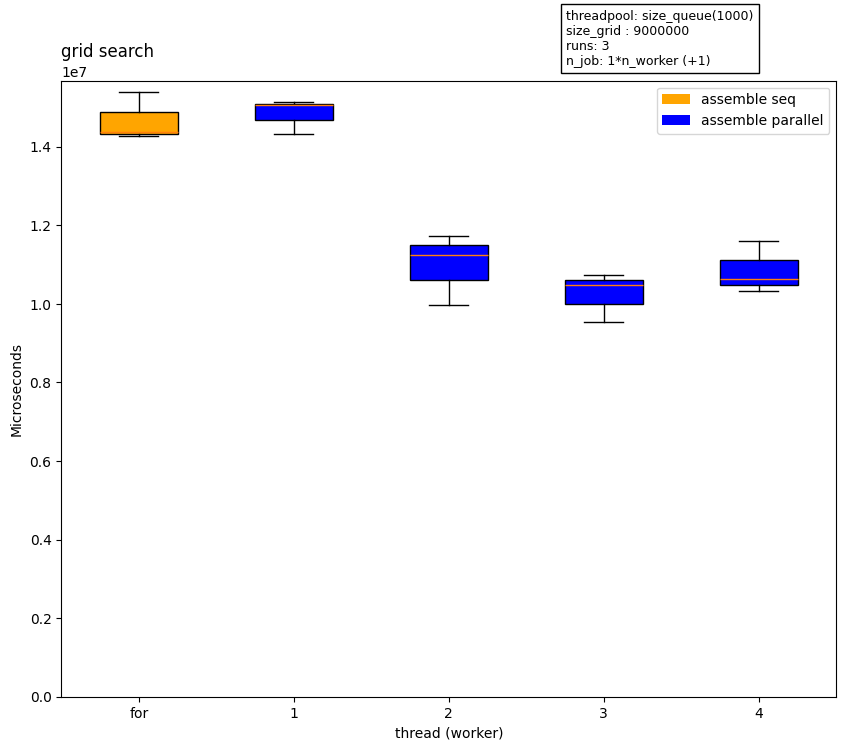

In [51]:
plot_granularity(dati_assemble, dati_assemble_parallel,"grid search")

su 3 iniziali tenuti 3 per for sequential
su 3 iniziali tenuti 3 per thread 1
su 3 iniziali tenuti 3 per thread 2
su 3 iniziali tenuti 3 per thread 3
su 3 iniziali tenuti 3 per thread 4


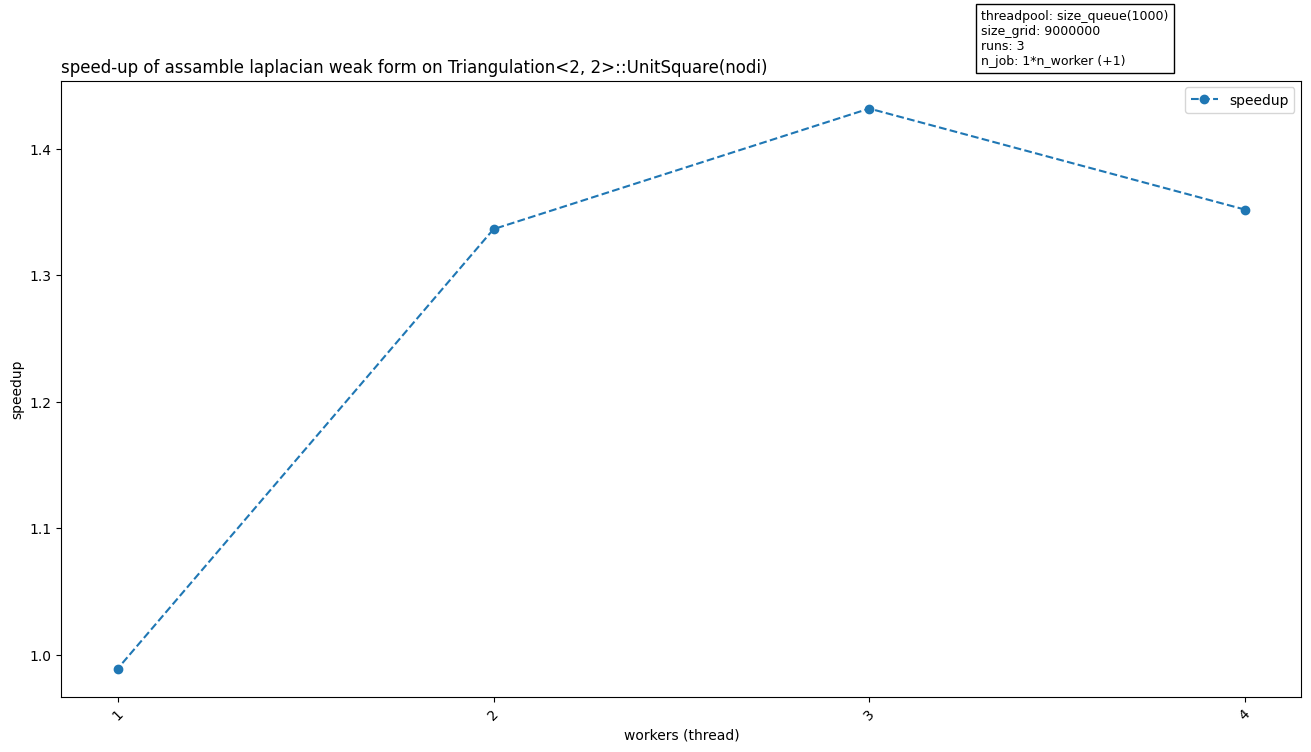

In [52]:
data_list = []
data_list.append(dati_assemble)
# Calcolo Q1, Q3 e IQR
Q1 = np.percentile(data_list[0], 25)
Q3 = np.percentile(data_list[0], 75)
IQR = Q3 - Q1

# Limiti per gli outlier
limite_inferiore = Q1 - 1.5 * IQR
limite_superiore = Q3 + 1.5 * IQR
#print(Q1,Q3,IQR,limite_inferiore,limite_superiore)
# Filtro
data_list[0] = data_list[0][(data_list[0] >= limite_inferiore) & (data_list[0] <= limite_superiore)]
print(f"su {len(dati_assemble)} iniziali tenuti {len(data_list[0])} per for sequential")
for i in range(len(n_threads)):
    data_list.append(dati_assemble_parallel[i])
    # Calcolo Q1, Q3 e IQR
    Q1 = np.percentile(data_list[i+1], 25)
    Q3 = np.percentile(data_list[i+1], 75)
    IQR = Q3 - Q1

    # Limiti per gli outlier
    limite_inferiore = Q1 - 1.5 * IQR
    limite_superiore = Q3 + 1.5 * IQR
   # print(Q1,Q3,IQR,limite_inferiore,limite_superiore)
    # Filtro
    data_list[i+1] = data_list[i+1][(data_list[i+1] >= limite_inferiore) & (data_list[i+1] <= limite_superiore)]
    print(f"su {len(dati_assemble_parallel[0])} iniziali tenuti {len(data_list[i+1])} per thread {n_threads[i]}")
plot_speedup_granularity(data_list,"speed-up of assamble laplacian weak form on Triangulation<2, 2>::UnitSquare(nodi)",n_threads,n_threads)

/mnt/c/Users/Cosimo Solidoro/Desktop/ProgettoPacs/plot/plot_assemble/boxplot_nodi50_assparr()32_k10